In [1]:
import numpy as np
import pandas as pd
import scvi
from scipy.sparse import csr_matrix
from scvi.model.utils import mde

/home/wergillius/.conda/envs/scvi-env/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/wergillius/.conda/envs/scvi-env/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (
/home/wergillius/.conda/envs/scvi-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.set_figure_params(figsize=(4, 4))

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
%config InlineBackend.figure_format='retina'

In [3]:
Fetal = sc.read_h5ad(
    "/home/wergillius/Project/diffuse_differentiate/data/Fetal_reference/GSE156793_protein_coding.h5ad"
)


TF_diff_raw2 = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/TFAtlas/TFAtlas_diff_rawcount.h5ad")

/home/wergillius/.conda/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [14]:
Fetal.var.index = [v.replace('.','-') for v in Fetal.var['gene_short_name'].values]

In [15]:
Fetal.var_names_make_unique()

```python
adata_diff = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad")


TF_raw = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/TFAtlas/GSE217460_210322_TFAtlas.h5ad")
TF_diff_raw = TF_raw[adata_diff.obs_names].copy()
TF_diff_raw.obs = adata_diff.obs
TF_diff_raw.uns = adata_diff.uns
TF_diff_raw.obsm = adata_diff.obsm
TF_diff_raw.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/TFAtlas/TFAtlas_diff_rawcount.h5ad")
```

In [16]:
overlap_genes = np.intersect1d(Fetal.var.index,TF_diff_raw2.var.index)

In [17]:
len(overlap_genes)

18558

In [18]:
TF_diff_raw2.X = csr_matrix(TF_diff_raw2.layers['counts'])

In [19]:
Fetal.obs['init-orig'] = 'Fetal_atlas'
TF_diff_raw2.obs['init-orig'] = 'TF_atlas'

In [20]:
TF_diff_raw2.obs['Batch'] = TF_diff_raw2.obs['batch'].apply(lambda x: str(int(x)+11))

In [21]:
adata = Fetal[:,overlap_genes].concatenate(TF_diff_raw2[:,overlap_genes])

/home/wergillius/.conda/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


In [22]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # keep full dimension safe

In [40]:
from importlib import reload

In [24]:
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=2000,
    layer="counts",
    batch_key="Batch",
    subset=True,
)

In [26]:
adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Fetal_reference/Fetal_TF_atlas_raw.h5ad")

# Integration with scVI
- Register the AnnData object with the correct key to identify the sample.

- Create an SCVI model object.

In [27]:
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="Batch")
vae = scvi.model.SCVI(adata, n_layers=2, n_latent=512)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [33]:
import jax
import pytorch_lightning as pl
import torch

In [36]:
pl.Trainer(accelerator='cuda',max_epochs=100)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [35]:
vae.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Epoch 2/2: 100%|██████████| 2/2 [07:06<00:00, 212.83s/it, v_num=1, train_loss_step=259, train_loss_epoch=282]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 2/2: 100%|██████████| 2/2 [07:06<00:00, 213.02s/it, v_num=1, train_loss_step=259, train_loss_epoch=282]


In [37]:
adata.obsm["X_scVI"] = vae.get_latent_representation()

In [49]:
np.save("/home/wergillius/Project/diffuse_differentiate/result
/home/wergillius/Project/diffuse_differentiate/data/Fetal_reference/scVI_latent.npy", adata.obsm["X_scVI"].copy())

FileNotFoundError: [Errno 2] No such file or directory: '../../data/Fetal_reference/scVI_latent.npy'

In [41]:
reload(scvi)

<module 'scvi' from '/home/wergillius/.conda/envs/scvi-env/lib/python3.9/site-packages/scvi/__init__.py'>

In [43]:
adata.obsm["X_mde"] = scvi.model.utils.mde(adata.obsm["X_scVI"])

/home/wergillius/.conda/envs/scvi-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


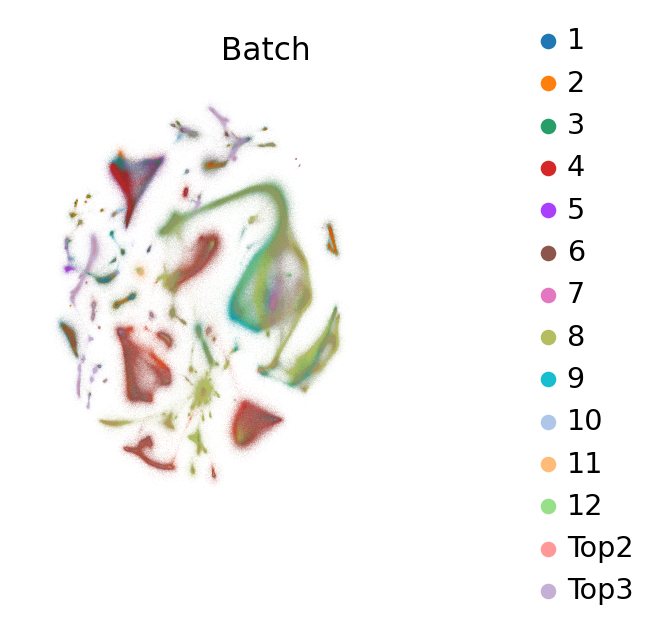

In [44]:
sc.pl.embedding(
    adata,
    basis="X_mde",
    color=["Batch"],
    frameon=False,
    ncols=1,
)

In [ ]:
TF_diff_raw2 = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/TFAtlas/TFAtlas_diff_rawcount.h5ad")